# Customer Order Classification

고객과 주문 데이터를 결합하고,  
`CASE WHEN`과 `HAVING`을 이용해 고객을 주문 활동 수준에 따라 분류한다.

## 분석 질문

1. 고객별 전체 주문 건수는 몇 건인가?
2. 고객별 결제완료 및 취소 주문은 몇 건인가?
3. 마지막 주문일은 언제인가?
4. 주문 건수에 따라 고객을 어떻게 분류할 수 있는가?
5. 주문이 2건 이상인 고객은 누구인가?

In [1]:
# 라이브러리
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 경로 설정
project_root = Path.cwd().parent
study_root = project_root.parent.parent

db_path = study_root / "SQL" / "database" / "retail_lab.db"
output_dir = project_root / "outputs"

output_dir.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Database path:", db_path)
print("Database exists:", db_path.exists())

Project root: d:\Study\Projects\00_foundation_review
Database path: d:\Study\SQL\database\retail_lab.db
Database exists: True


In [3]:
# 데이터베이스 연결
conn = sqlite3.connect(db_path)

In [4]:
# 최종 분류 쿼리
classification_query = """
SELECT
    c.customer_id,
    c.customer_name,
    c.region,
    c.grade,

    CASE
        WHEN c.grade = 'VIP' THEN 'Premium'
        WHEN c.grade = 'GOLD' THEN 'Gold'
        ELSE 'Basic'
    END AS customer_type,

    COUNT(o.order_id) AS total_order_count,

    SUM(
        CASE
            WHEN o.status = 'paid' THEN 1
            ELSE 0
        END
    ) AS paid_order_count,

    SUM(
        CASE
            WHEN o.status = 'cancelled' THEN 1
            ELSE 0
        END
    ) AS cancelled_order_count,

    MAX(o.order_date) AS last_order_date,

    CASE
        WHEN COUNT(o.order_id) >= 2 THEN 'Active'
        WHEN COUNT(o.order_id) = 1 THEN 'Normal'
        ELSE 'Inactive'
    END AS activity_level

FROM customers AS c
LEFT JOIN orders AS o
    ON c.customer_id = o.customer_id
GROUP BY
    c.customer_id,
    c.customer_name,
    c.region,
    c.grade
ORDER BY
    total_order_count DESC,
    c.customer_id
"""

classification_df = pd.read_sql(
    classification_query,
    conn
)

classification_df

,customer_id,customer_name,region,grade,customer_type,total_order_count,paid_order_count,cancelled_order_count,last_order_date,activity_level
0,1,Kim,Seoul,VIP,Premium,2,2,0,2026-07-22,Active
1,2,Lee,Busan,BASIC,Basic,1,1,0,2026-07-21,Normal
2,3,Park,Seoul,GOLD,Gold,1,0,1,2026-07-23,Normal
3,4,Choi,Incheon,BASIC,Basic,0,0,0,NaN,Inactive


In [5]:
# 날짜 변환
classification_df["last_order_date"] = pd.to_datetime(
    classification_df["last_order_date"]
)

classification_df.dtypes

customer_id                       int64
customer_name                       str
region                              str
grade                               str
customer_type                       str
total_order_count                 int64
paid_order_count                  int64
cancelled_order_count             int64
last_order_date          datetime64[us]
activity_level                      str
dtype: object

In [6]:
# 활동 수준별 고객 수
activity_summary_df = (
    classification_df
    .groupby("activity_level", as_index=False)
    .agg(customer_count=("customer_id", "count"))
    .sort_values("customer_count", ascending=False)
)

activity_summary_df

,activity_level,customer_count
2,Normal,2
0,Active,1
1,Inactive,1


In [7]:
# HAVING 쿼리 실행
active_customer_query = """
SELECT
    c.customer_id,
    c.customer_name,
    COUNT(o.order_id) AS order_count
FROM customers AS c
INNER JOIN orders AS o
    ON c.customer_id = o.customer_id
GROUP BY
    c.customer_id,
    c.customer_name
HAVING COUNT(o.order_id) >= 2
ORDER BY order_count DESC
"""

active_customer_df = pd.read_sql(
    active_customer_query,
    conn
)

active_customer_df

,customer_id,customer_name,order_count
0,1,Kim,2


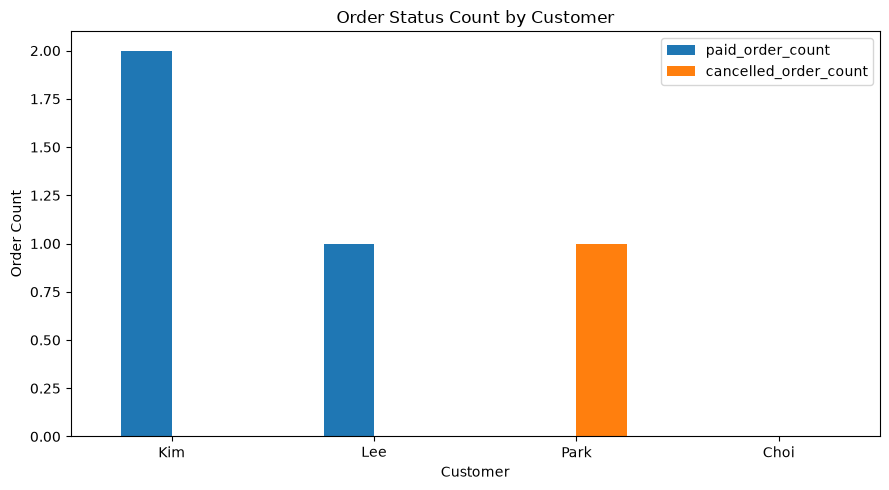

In [8]:
# 그래프
ax = classification_df.plot.bar(
    x="customer_name",
    y=[
        "paid_order_count",
        "cancelled_order_count"
    ],
    figsize=(9, 5)
)

ax.set_title("Order Status Count by Customer")
ax.set_xlabel("Customer")
ax.set_ylabel("Order Count")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
# csv 저장
output_path = (
    output_dir
    / "customer_order_classification.csv"
)

classification_df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d"
)

print("CSV 저장 완료")
print(output_path)

CSV 저장 완료
d:\Study\Projects\00_foundation_review\outputs\customer_order_classification.csv


In [13]:
# 저장 결과 검증
saved_df = pd.read_csv(
    output_path,
    encoding="utf-8-sig",
    parse_dates = ["last_order_date"]
)

saved_df

,customer_id,customer_name,region,grade,customer_type,total_order_count,paid_order_count,cancelled_order_count,last_order_date,activity_level
0,1,Kim,Seoul,VIP,Premium,2,2,0,2026-07-22,Active
1,2,Lee,Busan,BASIC,Basic,1,1,0,2026-07-21,Normal
2,3,Park,Seoul,GOLD,Gold,1,0,1,2026-07-23,Normal
3,4,Choi,Incheon,BASIC,Basic,0,0,0,NaT,Inactive


In [14]:
# 연결 종료
conn.close()

print("데이터베이스 연결 종료")

데이터베이스 연결 종료


## 분석 결과

- Kim은 주문이 2건으로 가장 많아 `Active` 고객으로 분류되었다.
- Lee와 Park는 주문이 각각 1건으로 `Normal` 고객으로 분류되었다.
- Choi는 주문 기록이 없어 `Inactive` 고객으로 분류되었다.
- Park의 주문은 취소 상태이므로 결제완료 주문 수는 0건이다.
- 주문 건수를 기준으로 고객을 분류할 때 `CASE WHEN`을 활용할 수 있다.

## 해석 시 주의점

현재 활동 수준 기준은 학습 목적으로 임의 설정한 것이다.

- Active: 주문 2건 이상
- Normal: 주문 1건
- Inactive: 주문 0건

실제 업무에서는 분석 기간, 구매금액, 최근 주문일 등을 함께 고려하여 고객 분류 기준을 정해야 한다.